Reaction mechanism: 
1) $H_2 + 2[*] \rightleftharpoons 2H^*$ 
2) $C_2H_2 + [*] \rightleftharpoons C_2H_2^*$ 
3) $C_2H_2^* + H^* \rightleftharpoons C_2H_3^* + [*]$ 
4) $C_2H_3^* + H^* \rightleftharpoons C_2H_4^* + [*]$ 
5) $C_2H_4^* \rightleftharpoons C_2H_4 + [*]$ 
6) $C_2H_4^* + H^* \rightleftharpoons C_2H_5^* + [*]$ 
7) $C_2H_5^* + H^* \rightleftharpoons C_2H_6 + 2[*]$

Running Temperature Sweep...


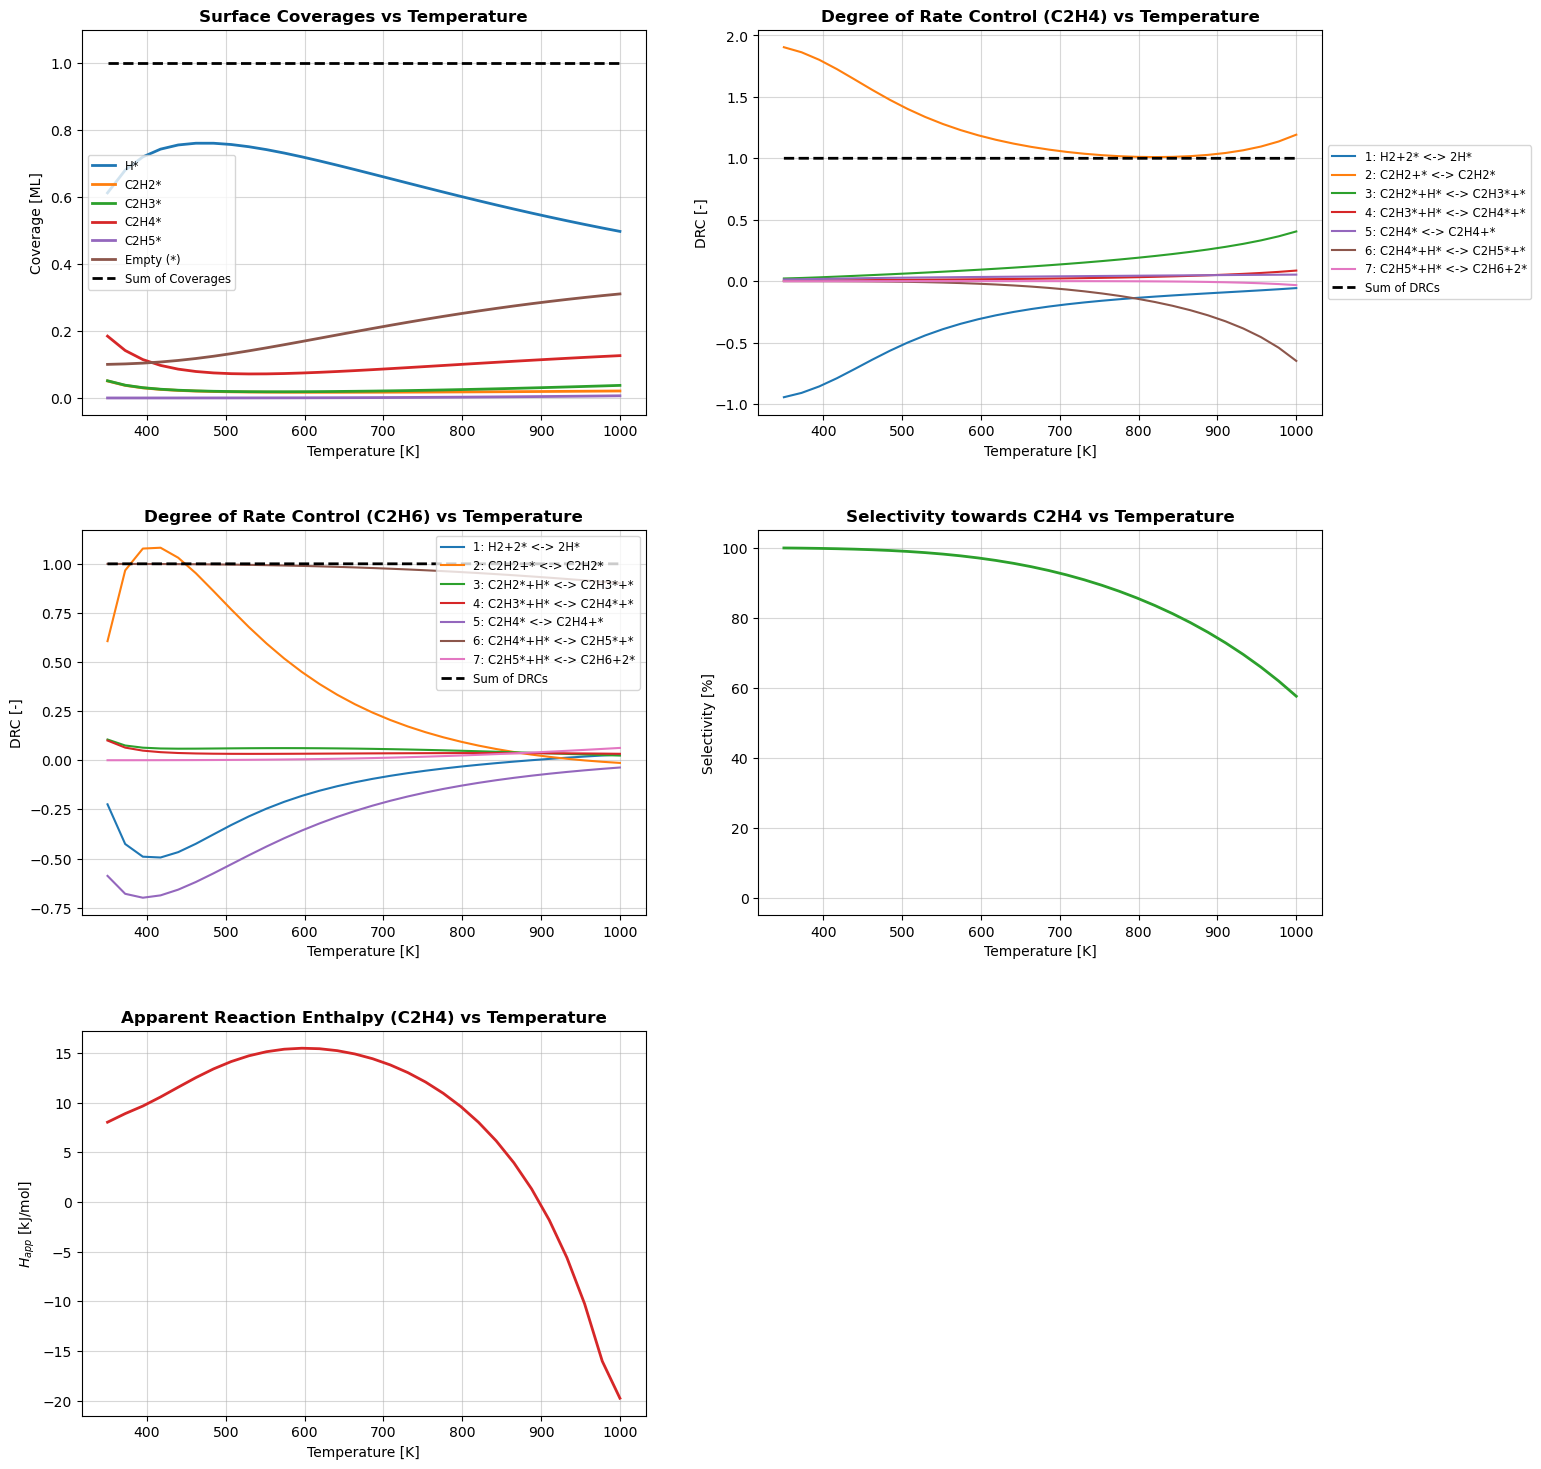

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares, root
import pandas as pd

# Constants
R = 8.314        # [J/mol.K] 
kb_J = 1.38e-23  # [J/K]
kb_eV = 8.617e-5 # [eV/K]
h = 6.626e-34    # [J.s]
N_a = 6.022e23   # [1/mol]

# Reactor and inlet feed conditions 
P = 1 # Pressure [bar]
y_in = np.zeros(4)
y_in[0] = 0.1  # H2
y_in[1] = 0.01 # C2H2
y_in[2] = 0.7  # C2H4
y_in[3] = 0.02 # C2H6
n_gas = len(y_in)
P_gas = P * y_in

# Reaction free energies (deltaG) in kJ/mol
deltaG = np.zeros(7)
deltaG[0] = -30 # H2 dissociative adsorption energy
deltaG[1] = -25 # C2H2 adsorption energy
deltaG[2] = -10 # First H addition
deltaG[3] = -10 # Second H addition
deltaG[4] = -5  # C2H4 desorption energy
deltaG[5] = 5   # Third H addition
deltaG[6] = -15 # Fourth H addition and C2H6 desorption 

# Activation free energies (Gact) in kJ/mol
Gact = np.zeros(7)
Gact[0] = 5  # H2 dissociative adsorption
Gact[1] = 5  # C2H2 adsorption
Gact[2] = 15 # First H addition
Gact[3] = 15 # Second H addition
Gact[4] = 20 # C2H4 desorption
Gact[5] = 40 # Third H addition
Gact[6] = 15 # Fourth H addition and C2H6 desorption

# Stoichiometric matrix (rows are species, columns are reactions)
nu_matrix = np.array([[-1,  0,  0,  0,  0,  0,  0],  # H2
                      [ 0, -1,  0,  0,  0,  0,  0],  # C2H2
                      [ 0,  0,  0,  0,  1,  0,  0],  # C2H4
                      [ 0,  0,  0,  0,  0,  0,  1],  # C2H6
                      [ 2,  0, -1, -1,  0, -1, -1],  # H*
                      [ 0,  1, -1,  0,  0,  0,  0],  # C2H2*
                      [ 0,  0,  1, -1,  0,  0,  0],  # C2H3*
                      [ 0,  0,  0,  1, -1, -1,  0],  # C2H4* 
                      [ 0,  0,  0,  0,  0,  1, -1],  # C2H5*
                      [-2, -1,  1,  1,  1,  1,  2]]) # Empty sites

# Isolate reactant and product stoichiometric coefficients
react_matrix = np.where(nu_matrix < 0, -nu_matrix, 0) 
prod_matrix = np.where(nu_matrix > 0, nu_matrix, 0)    

# Solver function setup
def ss_cstr_mkm(x_log, kf_current, kb_current): 
    theta = np.exp(x_log)
    activities = np.concatenate((P_gas, theta))
    r_f = kf_current * np.prod(activities[:, None] ** react_matrix, axis=0)
    r_b = kb_current * np.prod(activities[:, None] ** prod_matrix, axis=0)
    r_net = r_f - r_b 
    species_rates = nu_matrix @ r_net 
    residuals = species_rates[n_gas:-1]
    scaling_factor = np.max(r_f) + 1e-20
    residuals = residuals / scaling_factor
    residuals = np.append(residuals, (np.sum(theta) - 1.0)) # Site conservation
    return residuals

def calculate_rates(theta, kf_current, kb_current):
    activities = np.concatenate((P_gas, theta))
    r_f = kf_current * np.prod(activities[:, None] ** react_matrix, axis=0)
    r_b = kb_current * np.prod(activities[:, None] ** prod_matrix, axis=0)
    return r_f, r_b

# Temperature Sweep Setup
T_range = np.linspace(350, 1000, 30) # 300K to 1000K, steps of 10K
epsilon = 1e-4 # Perturbation factor for DRC

# Initial guesses
initial_guess = np.array([0.8, 0.05, 0.05, 0.02, 0.03, 0.05])
current_guess_log = np.log(initial_guess)

# Storage arrays
cov_all = []
drc_c2h4_all = []
drc_c2h6_all = []
rate_c2h4_all = []
rate_c2h6_all = []

print("Running Temperature Sweep...")
for T in T_range:
    # Calculate Temp dependent parameters
    K_eq = np.exp(-deltaG * 1e3 / (R * T))
    kf = kb_J * T / h * np.exp(-Gact * 1e3 / (R * T))
    kb = kf / K_eq
    
    # Solve for Steady State Coverages
    sol_log = least_squares(ss_cstr_mkm, current_guess_log, 
                            args=(kf, kb), ftol=1e-12, xtol=1e-12, gtol=1e-12,
                            x_scale='jac', bounds=(-np.inf, 0))
    # sol_log = root(ss_cstr_mkm, current_guess_log, args=(kf, kb), method='lm', tol=1e-12)
    if abs(sol_log.fun[-1]) > 1e-6: 
        print(T)
    # current_guess_log = sol_log.x # Use as guess for next T iteration
    theta = np.exp(sol_log.x)
    cov_all.append(theta)
    
    # Base Rates
    r_f, r_b = calculate_rates(theta, kf, kb)
    r_C2H4 = r_f[4] - r_b[4] # C2H4 net production (Reaction 5)
    r_C2H6 = r_f[6] - r_b[6] # C2H6 net production (Reaction 7)
    
    rate_c2h4_all.append(r_C2H4)
    rate_c2h6_all.append(r_C2H6)
    
    # Calculate DRCs
    DRC_C2H4 = np.zeros(7)
    DRC_C2H6 = np.zeros(7)
    
    for i in range(7):
        kf_pert = np.copy(kf)
        kb_pert = np.copy(kb)
        
        # Perturb forward rate and adjust backward rate to keep equilibrium
        kf_pert[i] = kf[i] * (1 + epsilon)
        kb_pert[i] = kf_pert[i] / K_eq[i]
        
        sol_pert_log = least_squares(ss_cstr_mkm, sol_log.x, 
                                     args=(kf_pert, kb_pert), ftol=1e-12, xtol=1e-12, gtol=1e-12, 
                                     x_scale='jac', bounds=(-np.inf, 0))
        # sol_pert_log = root(ss_cstr_mkm, sol_log.x, args=(kf_pert, kb_pert), method='lm', tol=1e-12)
        if abs(sol_pert_log.fun[-1]) > 1e-6: 
            print(T)
        r_f_p, r_b_p = calculate_rates(np.exp(sol_pert_log.x), kf_pert, kb_pert)
        
        r_C2H4_pert = r_f_p[4] - r_b_p[4]
        r_C2H6_pert = r_f_p[6] - r_b_p[6]
        
        # Prevent division by zero if rates approach zero
        DRC_C2H4[i] = (r_C2H4_pert - r_C2H4) / (r_C2H4 * epsilon) if abs(r_C2H4) > 1e-15 else 0
        DRC_C2H6[i] = (r_C2H6_pert - r_C2H6) / (r_C2H6 * epsilon) if abs(r_C2H6) > 1e-15 else 0
            
    drc_c2h4_all.append(DRC_C2H4)
    drc_c2h6_all.append(DRC_C2H6)

# Convert outputs to numpy arrays for plotting
cov_all = np.array(cov_all)
drc_c2h4_all = np.array(drc_c2h4_all)
drc_c2h6_all = np.array(drc_c2h6_all)
rate_c2h4_all = np.array(rate_c2h4_all)
rate_c2h6_all = np.array(rate_c2h6_all)

# Calculated Quantities
sum_covs = np.sum(cov_all, axis=1)
sum_drc_c2h4 = np.sum(drc_c2h4_all, axis=1)
sum_drc_c2h6 = np.sum(drc_c2h6_all, axis=1)

# Selectivity (handling near-zero rate sums safely)
total_rate = np.abs(rate_c2h4_all) + np.abs(rate_c2h6_all)
selectivity_c2h4 = np.divide(np.abs(rate_c2h4_all), total_rate, out=np.zeros_like(rate_c2h4_all), where=total_rate!=0)

# Apparent Enthalpy H_app = R*T^2 * d(ln(r))/dT
# Using np.abs() to handle potential negative net production near equilibrium
ln_rate_c2h4 = np.log(np.maximum(np.abs(rate_c2h4_all), 1e-20)) 
d_ln_r_dT = np.gradient(ln_rate_c2h4, T_range)
H_app_c2h4 = R * (T_range**2) * d_ln_r_dT / 1000 # Divided by 1000 for kJ/mol

# --- Plotting ---
surf_names = ['H*', 'C2H2*', 'C2H3*', 'C2H4*', 'C2H5*', 'Empty (*)']
reaction_names = [
    "1: H2+2* <-> 2H*", "2: C2H2+* <-> C2H2*", "3: C2H2*+H* <-> C2H3*+*",
    "4: C2H3*+H* <-> C2H4*+*", "5: C2H4* <-> C2H4+*", 
    "6: C2H4*+H* <-> C2H5*+*", "7: C2H5*+H* <-> C2H6+2*"]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# 1. Coverages
ax = axes[0, 0]
for i in range(6):
    ax.plot(T_range, cov_all[:, i], label=surf_names[i], linewidth=2)
ax.plot(T_range, sum_covs, '--k', label='Sum of Coverages', linewidth=2)
ax.set_title('Surface Coverages vs Temperature', fontweight='bold')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Coverage [ML]')
ax.set_ylim(-0.05, 1.1)
ax.legend(loc='best', fontsize='small')
ax.grid(True, alpha=0.5)

# 2. DRC for C2H4
ax = axes[0, 1]
for i in range(7):
    ax.plot(T_range, drc_c2h4_all[:, i], label=reaction_names[i])
ax.plot(T_range, sum_drc_c2h4, '--k', label='Sum of DRCs', linewidth=2)
ax.set_title('Degree of Rate Control (C2H4) vs Temperature', fontweight='bold')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('DRC [-]')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
ax.grid(True, alpha=0.5)

# 3. DRC for C2H6
ax = axes[1, 0]
for i in range(7):
    ax.plot(T_range, drc_c2h6_all[:, i], label=reaction_names[i])
ax.plot(T_range, sum_drc_c2h6, '--k', label='Sum of DRCs', linewidth=2)
ax.set_title('Degree of Rate Control (C2H6) vs Temperature', fontweight='bold')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('DRC [-]')
ax.legend(loc='best', fontsize='small')
ax.grid(True, alpha=0.5)

# 4. Selectivity
ax = axes[1, 1]
ax.plot(T_range, selectivity_c2h4 * 100, color='tab:green', linewidth=2)
ax.set_title('Selectivity towards C2H4 vs Temperature', fontweight='bold')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Selectivity [%]')
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.5)

# 5. Apparent Enthalpy
ax = axes[2, 0]
ax.plot(T_range, H_app_c2h4, color='tab:red', linewidth=2)
ax.set_title('Apparent Reaction Enthalpy (C2H4) vs Temperature', fontweight='bold')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('$H_{app}$ [kJ/mol]')
ax.grid(True, alpha=0.5)

# Clear empty subplot
axes[2, 1].axis('off')

plt.show()

Calculating H2 Reaction Order...


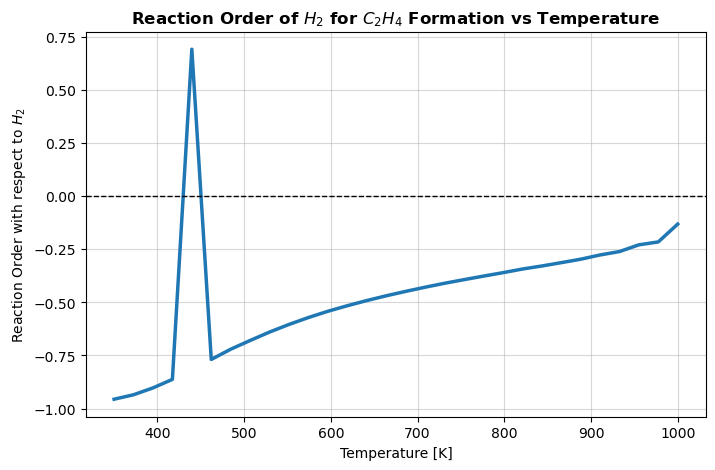

In [4]:
# =============================================================================
# H2 Reaction Order Calculation Block
# =============================================================================

print("Calculating H2 Reaction Order...")

# Define a perturbation factor for the H2 partial pressure (0.1%)
eps_P = 1e-3 

# Baseline and perturbed gas pressure arrays
P_gas_base = P * y_in
P_gas_pert = np.copy(P_gas_base)
P_gas_pert[0] = P_gas_base[0] * (1 + eps_P) # Perturb ONLY H2

# Helper function to solve the MKM for a specific gas composition
def get_rate_at_P(T_val, P_gas_local, guess_log):
    # Calculate Temp dependent parameters
    K_eq_local = np.exp(-deltaG * 1e3 / (R * T_val))
    kf_local = kb_J * T_val / h * np.exp(-Gact * 1e3 / (R * T_val))
    kb_local = kf_local / K_eq_local

    def local_ss_mkm(x_log):
        theta_local = np.exp(x_log)
        activities_local = np.concatenate((P_gas_local, theta_local))
        r_f_local = kf_local * np.prod(activities_local[:, None] ** react_matrix, axis=0)
        r_b_local = kb_local * np.prod(activities_local[:, None] ** prod_matrix, axis=0)
        r_net_local = r_f_local - r_b_local 
        
        species_rates_local = nu_matrix @ r_net_local 
        residuals_local = species_rates_local[n_gas:-1]
        scaling = np.max(r_f_local) + 1e-20
        residuals_local = residuals_local / scaling
        residuals_local = np.append(residuals_local, (np.sum(theta_local) - 1.0))
        return residuals_local

    # Solve
    sol = least_squares(local_ss_mkm, guess_log, ftol=1e-12, xtol=1e-12, gtol=1e-12, 
                        x_scale='jac', bounds=(-np.inf, 0))
    
    # Calculate final rates
    theta_final = np.exp(sol.x)
    activities_final = np.concatenate((P_gas_local, theta_final))
    r_f_final = kf_local * np.prod(activities_final[:, None] ** react_matrix, axis=0)
    r_b_final = kb_local * np.prod(activities_final[:, None] ** prod_matrix, axis=0)
    
    r_C2H4_net = r_f_final[4] - r_b_final[4]
    return r_C2H4_net, sol.x

# Storage array for reaction orders
reaction_order_H2 = []

# Reset initial guess for the new sweep
current_guess_log = np.log(initial_guess)

for T in T_range:
    # 1. Get baseline rate 
    rate_base, current_guess_log = get_rate_at_P(T, P_gas_base, current_guess_log)
    
    # 2. Get perturbed rate (using the base solution as a highly accurate initial guess)
    rate_pert, _ = get_rate_at_P(T, P_gas_pert, current_guess_log)
    
    # 3. Calculate Reaction Order: d(ln(r)) / d(ln(P))
    # Note: Using absolute values to handle cases where net rate approaches/crosses zero near equilibrium
    if abs(rate_base) > 1e-15 and abs(rate_pert) > 1e-15:
        order = np.log(abs(rate_pert) / abs(rate_base)) / np.log(1 + eps_P)
    else:
        order = 0.0
        
    reaction_order_H2.append(order)

reaction_order_H2 = np.array(reaction_order_H2)

# --- Plotting the Reaction Order ---
plt.figure(figsize=(8, 5))
plt.plot(T_range, reaction_order_H2, color='tab:blue', linewidth=2.5)
plt.title('Reaction Order of $H_2$ for $C_2H_4$ Formation vs Temperature', fontweight='bold')
plt.xlabel('Temperature [K]')
plt.ylabel('Reaction Order with respect to $H_2$')
plt.grid(True, alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Reference line at zero
plt.show()